In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_diabetes

In [3]:
diabetes = load_diabetes()

In [4]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

In [5]:
diabetes_df = pd.DataFrame(data = diabetes.data, columns = ['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])

In [6]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [7]:
X = diabetes_df
y = diabetes['target']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

<Axes: >

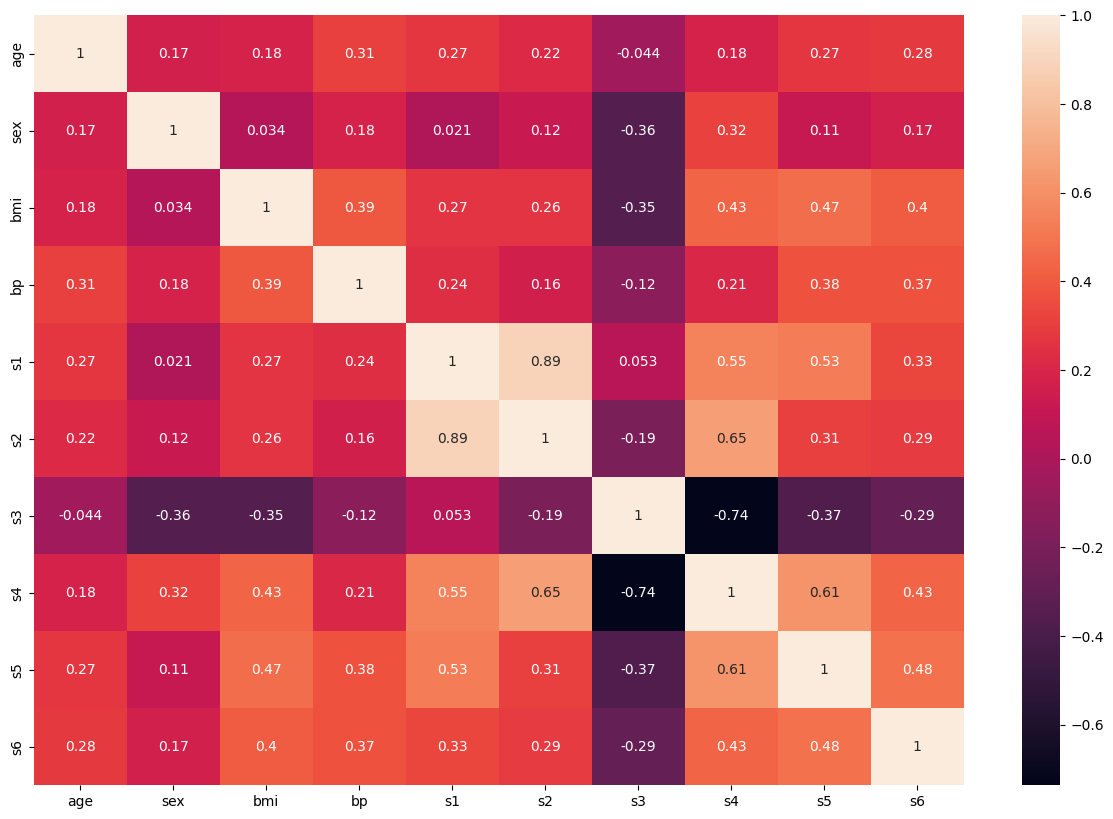

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(), annot=True)

In [11]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
treeregressor= DecisionTreeRegressor()

In [13]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error','poisson'],
    'splitter':['best', 'random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features': ['auto','sqrt','log2']
}

In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
grid = GridSearchCV(estimator = treeregressor, param_grid=param, cv = 5,scoring='neg_mean_squared_error')

In [16]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [17]:
grid.best_params_

{'criterion': 'poisson',
 'max_depth': 2,
 'max_features': 'auto',
 'splitter': 'best'}

In [18]:
y_pred = grid.predict(X_test)

In [19]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.2770138039725839
49.420120264583645
3830.490578636021


In [20]:
selectedmodel = DecisionTreeRegressor(criterion= 'squared_error',
 max_depth= 3,
 max_features= 'sqrt',
 splitter= 'best')

In [21]:
selectedmodel.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=3, max_features='sqrt')

[Text(0.5, 0.875, 'x[8] <= -0.0\nsquared_error = 6076.398\nsamples = 353\nvalue = 153.737'),
 Text(0.25, 0.625, 'x[3] <= 0.024\nsquared_error = 3532.233\nsamples = 181\nvalue = 113.193'),
 Text(0.125, 0.375, 'x[2] <= 0.006\nsquared_error = 2638.766\nsamples = 150\nvalue = 104.633'),
 Text(0.0625, 0.125, 'squared_error = 1965.033\nsamples = 126\nvalue = 95.175'),
 Text(0.1875, 0.125, 'squared_error = 3240.207\nsamples = 24\nvalue = 154.292'),
 Text(0.375, 0.375, 'x[4] <= -0.016\nsquared_error = 5785.334\nsamples = 31\nvalue = 154.613'),
 Text(0.3125, 0.125, 'squared_error = 5450.44\nsamples = 10\nvalue = 194.4'),
 Text(0.4375, 0.125, 'squared_error = 4832.032\nsamples = 21\nvalue = 135.667'),
 Text(0.75, 0.625, 'x[5] <= -0.004\nsquared_error = 5203.659\nsamples = 172\nvalue = 196.401'),
 Text(0.625, 0.375, 'x[3] <= 0.017\nsquared_error = 5335.959\nsamples = 64\nvalue = 217.297'),
 Text(0.5625, 0.125, 'squared_error = 5275.286\nsamples = 25\nvalue = 177.56'),
 Text(0.6875, 0.125, 'square

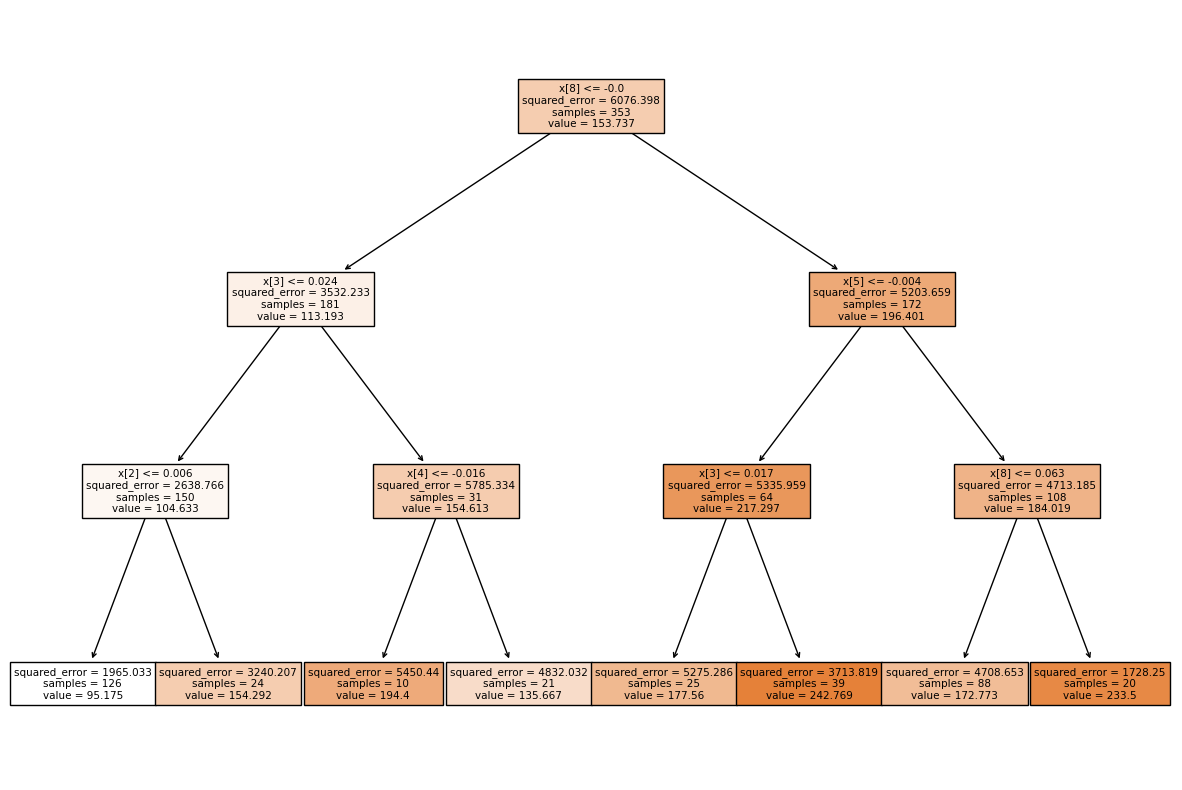

In [22]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectedmodel,filled=True)